**Customer Segmentation Project**

# Step 1: Import Required Libraries

In this step, we import all the Python libraries required for the project. These libraries are used for data manipulation, visualization, preprocessing, clustering, and model evaluation.


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Step 2: Load the Dataset

The customer dataset is loaded into a Pandas DataFrame. This dataset contains demographic and purchasing information that will be used for customer segmentation.

In [2]:
df = pd.read_csv("/content/Mall_Customers.csv")

# Step 3: Display the Dataset

The first five records of the dataset are displayed to understand its structure and verify that the data has been loaded correctly.

In [3]:
df.head()


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
df.shape

(200, 5)

# Step 4: Explore the Dataset

This step displays information about the dataset, including the number of rows, columns, data types, and memory usage.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


# Step 5: Check Missing Values

Before performing clustering, it is important to verify whether the dataset contains any missing values. Missing values can affect the performance of the clustering algorithm.

In [6]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


# Step 6: Check Duplicate Records

This step identifies duplicate records in the dataset. Removing duplicates helps improve the quality and reliability of the analysis.


In [7]:
df.duplicated().sum()

np.int64(0)

# Step 7: Statistical Summary

The statistical summary provides information such as the mean, minimum, maximum, and standard deviation of the numerical features.

In [8]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


# Step 8: Encode Categorical Features

Machine learning algorithms require numerical input. Therefore, categorical columns such as Gender are converted into numerical values using Label Encoding.

In [9]:
encoder = LabelEncoder()

df["Gender"] = encoder.fit_transform(df["Gender"])

In [10]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,1,19,15,39
1,2,1,21,15,81
2,3,0,20,16,6
3,4,0,23,16,77
4,5,0,31,17,40


# Step 9: Feature Selection

Only the relevant features required for customer segmentation are selected. The CustomerID column is excluded because it does not contribute to clustering.

In [11]:
X = df.drop("CustomerID", axis=1)

In [12]:
X.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40


# Step 10: Feature Scaling

The selected features are standardized using StandardScaler. Scaling ensures that all features contribute equally to the clustering process.

In [13]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Step 11: Apply K-Means Clustering

The K-Means clustering algorithm is applied using the optimal number of clusters obtained from the Elbow Method.

In [14]:
wcss = []

for i in range(1,11):
    model = KMeans(n_clusters=i, random_state=42)
    model.fit(X_scaled)
    wcss.append(model.inertia_)

# Step 12: Visualize Customer Segments

A scatter plot is used to visualize the customer segments. Different colors represent different customer groups identified by the K-Means algorithm.

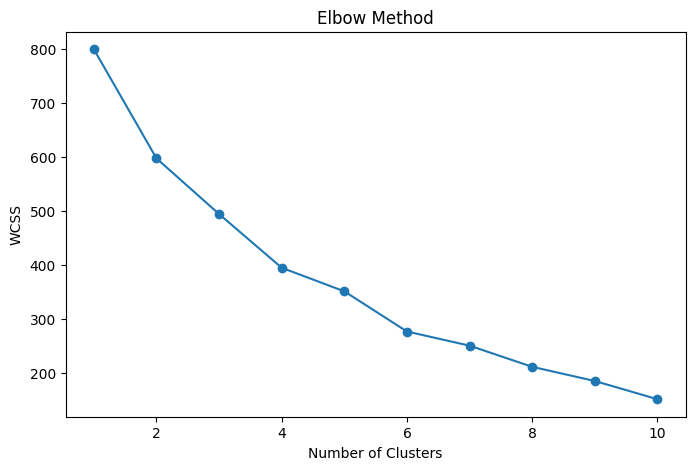

In [15]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.show()

In [16]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42
)

clusters = kmeans.fit_predict(X_scaled)

In [17]:
df["Cluster"] = clusters

In [18]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,1,19,15,39,2
1,2,1,21,15,81,2
2,3,0,20,16,6,4
3,4,0,23,16,77,4
4,5,0,31,17,40,4


In [19]:
df["Cluster"].value_counts()

,count
Cluster,
0,51
3,49
2,42
4,38
1,20


In [20]:
centers = scaler.inverse_transform(kmeans.cluster_centers_)

centers_df = pd.DataFrame(
    centers,
    columns=X.columns
)

centers_df

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,5.098039e-01,56.470588,46.098039,39.313725
1,1.000000e+00,39.500000,85.150000,14.050000
2,1.000000e+00,28.690476,60.904762,70.238095
3,-1.665335e-16,37.897959,82.122449,54.448980
4,1.665335e-16,27.315789,38.842105,56.210526


In [22]:
print(df.columns)

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)', 'Cluster'],
      dtype='object')


In [23]:
df.columns = df.columns.str.strip()

print(df.columns)

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)', 'Cluster'],
      dtype='object')


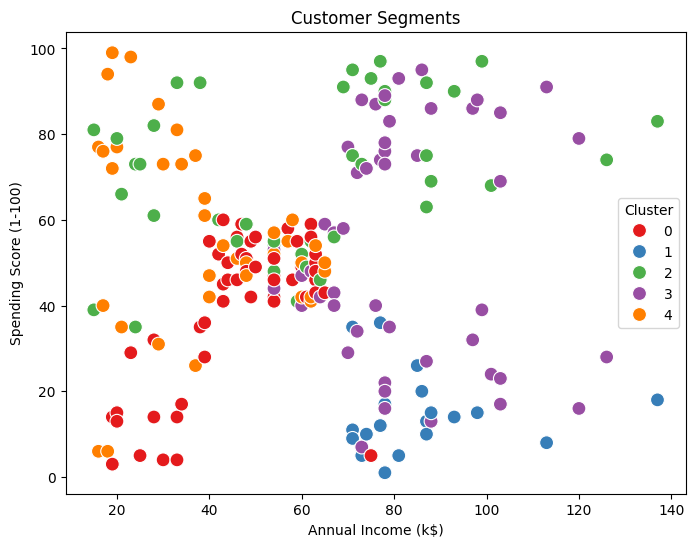

In [24]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df["Annual Income (k$)"],
    y=df["Spending Score (1-100)"],
    hue=df["Cluster"],
    palette="Set1",
    s=100
)

plt.title("Customer Segments")

plt.show()

# Step 13: Cluster Distribution

This step displays the number of customers present in each cluster.

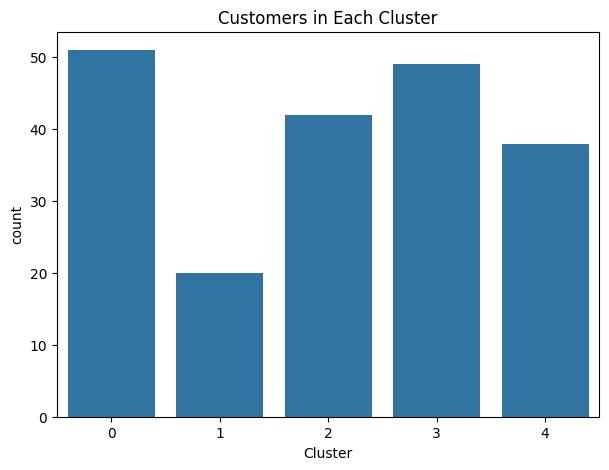

In [25]:
plt.figure(figsize=(7,5))

sns.countplot(
    x="Cluster",
    data=df
)

plt.title("Customers in Each Cluster")

plt.show()

In [26]:
cluster_summary = df.groupby("Cluster").mean()

cluster_summary

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,,,
0,65.333333,0.509804,56.470588,46.098039,39.313725
1,159.500000,1.000000,39.500000,85.150000,14.050000
2,100.809524,1.000000,28.690476,60.904762,70.238095
3,151.510204,0.000000,37.897959,82.122449,54.448980
4,50.526316,0.000000,27.315789,38.842105,56.210526


# Step 14: Analyze Cluster Characteristics

The average values of each feature are calculated for every cluster. This helps understand the characteristics and behavior of each customer group.

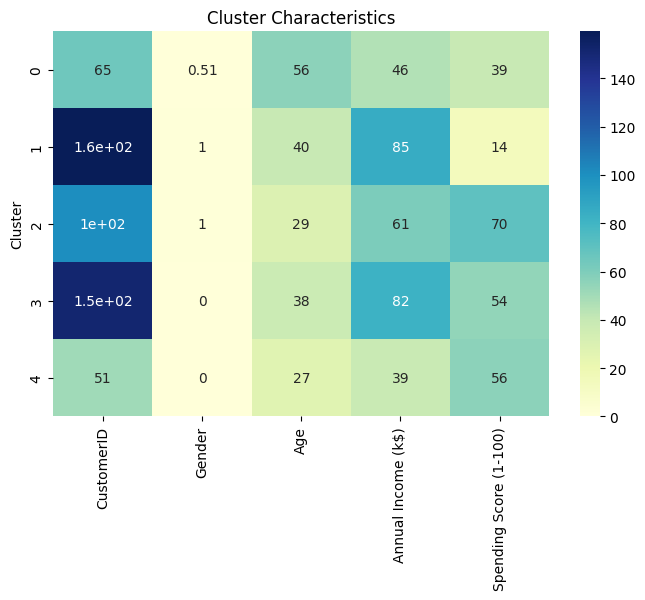

In [27]:
plt.figure(figsize=(8,5))

sns.heatmap(
    cluster_summary,
    annot=True,
    cmap="YlGnBu"
)

plt.title("Cluster Characteristics")

plt.show()

# Step 15: Evaluate Clustering Performance

The Silhouette Score is calculated to measure the quality of the clustering. A higher score indicates better-defined customer segments.

In [28]:
score = silhouette_score(X_scaled, clusters)

print(score)

0.27191023466188324


In [30]:
cluster_summary = df.groupby("Cluster").mean(numeric_only=True)
print(cluster_summary)

         CustomerID    Gender        Age  Annual Income (k$)  \
Cluster                                                        
0         65.333333  0.509804  56.470588           46.098039   
1        159.500000  1.000000  39.500000           85.150000   
2        100.809524  1.000000  28.690476           60.904762   
3        151.510204  0.000000  37.897959           82.122449   
4         50.526316  0.000000  27.315789           38.842105   

         Spending Score (1-100)  
Cluster                          
0                     39.313725  
1                     14.050000  
2                     70.238095  
3                     54.448980  
4                     56.210526  


# Step 16: Save the Final Output

The final dataset, including the assigned cluster labels, is saved as a CSV file for future analysis and reporting.

In [31]:
df.to_csv("Customer_Segmentation_Output.csv", index=False)

# Conclusion

The Customer Segmentation project successfully grouped customers into different clusters based on demographic and purchasing behavior using the K-Means clustering algorithm. These insights can help businesses understand customer preferences, design targeted marketing strategies, and improve customer relationship management.